# Statistical Physics: Ising Temperature Classification

Classify low-temperature versus high-temperature Ising samples from Monte Carlo correlation features. The quantum model uses the package angle embedding inside a precomputed quantum kernel and is checked against a logistic baseline.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** The Ising model is a standard statistical-physics model for interacting spins. The notebook uses Metropolis Monte Carlo samples from a small two-dimensional lattice and classifies whether each sample comes from a low-temperature or high-temperature regime.

**Explicit variables.** `lattice_size` is the side length of the square spin lattice. `temperature` is the Monte Carlo sampling temperature. `spins` is a matrix of spin values in `{−1, +1}`. `magnetization` is the absolute mean spin. `nn_correlation` is the nearest-neighbor spin correlation. `energy_density` is the normalized Ising energy. `x_raw = [magnetization, nn_correlation, energy_density]` is the feature vector. `y = 0` denotes low temperature and `y = 1` denotes high temperature. `k_train` and `k_test` are quantum-kernel matrices.

**Quantum advantage context.** Kernel methods are a natural way to compare structured physical samples. Quantum kernels may become interesting when the feature representation is high-dimensional or generated by quantum hardware. This small Monte Carlo notebook does **not** demonstrate quantum advantage; it validates a quantum-kernel classification workflow on a real statistical-physics system.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import pennylane as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from qml.reporting import print_section


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

from qml.embeddings import apply_angle_embedding
from qml.metrics import accuracy_score

## Domain simulator

A small two-dimensional Ising lattice is sampled with Metropolis updates. Each sample is summarized by absolute magnetization, nearest-neighbor correlation, and energy density.

In [2]:
def metropolis_ising_features(temperatures, *, lattice_size=8, burn_in=70, sweeps=45, seed=31):
    rng = np.random.default_rng(seed)
    features = []
    labels = []
    spins = rng.choice([-1, 1], size=(lattice_size, lattice_size))

    def energy_density(config):
        right = np.roll(config, shift=-1, axis=1)
        down = np.roll(config, shift=-1, axis=0)
        return -float(np.mean(config * right + config * down))

    def nn_correlation(config):
        right = np.roll(config, shift=-1, axis=1)
        down = np.roll(config, shift=-1, axis=0)
        return float(0.5 * np.mean(config * right + config * down))

    def sweep(config, temperature):
        for _ in range(lattice_size * lattice_size):
            i = rng.integers(0, lattice_size)
            j = rng.integers(0, lattice_size)
            neighbor_sum = (
                config[(i + 1) % lattice_size, j]
                + config[(i - 1) % lattice_size, j]
                + config[i, (j + 1) % lattice_size]
                + config[i, (j - 1) % lattice_size]
            )
            delta_energy = 2.0 * config[i, j] * neighbor_sum
            if delta_energy <= 0.0 or rng.random() < np.exp(-delta_energy / temperature):
                config[i, j] *= -1

    for temperature in temperatures:
        for _ in range(burn_in):
            sweep(spins, temperature)
        for _ in range(sweeps):
            sweep(spins, temperature)
        magnetization = abs(float(np.mean(spins)))
        features.append([magnetization, nn_correlation(spins), energy_density(spins)])
        labels.append(int(temperature >= 2.269))

    return np.asarray(features, dtype=float), np.asarray(labels, dtype=int)


low_t = np.linspace(1.35, 2.05, 24)
high_t = np.linspace(2.55, 3.45, 24)
temperatures = np.concatenate([low_t, high_t])
x_raw, y = metropolis_ising_features(temperatures)

print_section(
    "Dataset",
    [
        ("Samples", int(len(y))),
        ("feature_shape", list(x_raw.shape)),
        ("Labels", np.bincount(y).tolist()),
        ("Temperature range", [float(temperatures.min()), float(temperatures.max())]),
    ],
)

Dataset
+-------------------+--------------+
| Metric            | Value        |
+-------------------+--------------+
| Samples           | 48           |
| feature_shape     | [48, 3]      |
| Labels            | [24, 24]     |
| Temperature range | [1.35, 3.45] |
+-------------------+--------------+



## Quantum-kernel package client

In [3]:
def make_quantum_kernel(n_qubits, seed):
    wires = list(range(n_qubits))
    dev = pl.device("default.qubit", wires=n_qubits, seed=seed)

    def feature_map(x):
        apply_angle_embedding(x, wires=wires)
        if n_qubits > 1:
            for left, right in zip(wires[:-1], wires[1:]):
                pl.CNOT(wires=[left, right])

    @pl.qnode(dev)
    def kernel_circuit(x1, x2):
        feature_map(x1)
        pl.adjoint(feature_map)(x2)
        return pl.probs(wires=wires)

    def kernel_value(x1, x2):
        return float(kernel_circuit(x1, x2)[0])

    return kernel_value


def kernel_matrix(a, b, kernel_value):
    return np.asarray([[kernel_value(xi, xj) for xj in b] for xi in a], dtype=float)

In [4]:
x_train, x_test, y_train, y_test, t_train, t_test = train_test_split(
    x_raw, y, temperatures, test_size=0.3, random_state=31, stratify=y
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

kernel_value = make_quantum_kernel(n_qubits=x_train.shape[1], seed=31)
k_train = kernel_matrix(x_train, x_train, kernel_value)
k_test = kernel_matrix(x_test, x_train, kernel_value)

quantum_clf = SVC(kernel="precomputed")
quantum_clf.fit(k_train, y_train)
y_pred = quantum_clf.predict(k_test)

classical_clf = LogisticRegression(random_state=31, max_iter=1000)
classical_clf.fit(x_train, y_train)
y_classical = classical_clf.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, y_pred),
    "logistic_accuracy": accuracy_score(y_test, y_classical),
    "confusion_matrix": confusion_matrix(y_test, y_pred).astype(int).tolist(),
    "kernel_train_shape": list(k_train.shape),
    "kernel_diag_min": float(np.min(np.diag(k_train))),
    "kernel_symmetry_error": float(np.max(np.abs(k_train - k_train.T))),
}

print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
        ("Confusion matrix", results["confusion_matrix"]),
        ("Kernel train shape", results["kernel_train_shape"]),
        ("Kernel diagonal minimum", results["kernel_diag_min"]),
        ("Kernel symmetry error", results["kernel_symmetry_error"]),
    ],
)

Results
+-------------------------+------------------+
| Metric                  | Value            |
+-------------------------+------------------+
| Quantum kernel accuracy | 0.933333         |
| Logistic accuracy       | 0.933333         |
| Confusion matrix        | [[8, 0], [1, 6]] |
| Kernel train shape      | [33, 33]         |
| Kernel diagonal minimum | 1                |
| Kernel symmetry error   | 6.66134e-16      |
+-------------------------+------------------+



## Plots

The plots show the Ising correlation features, the quantum-kernel matrix, and the held-out phase predictions ordered by temperature.

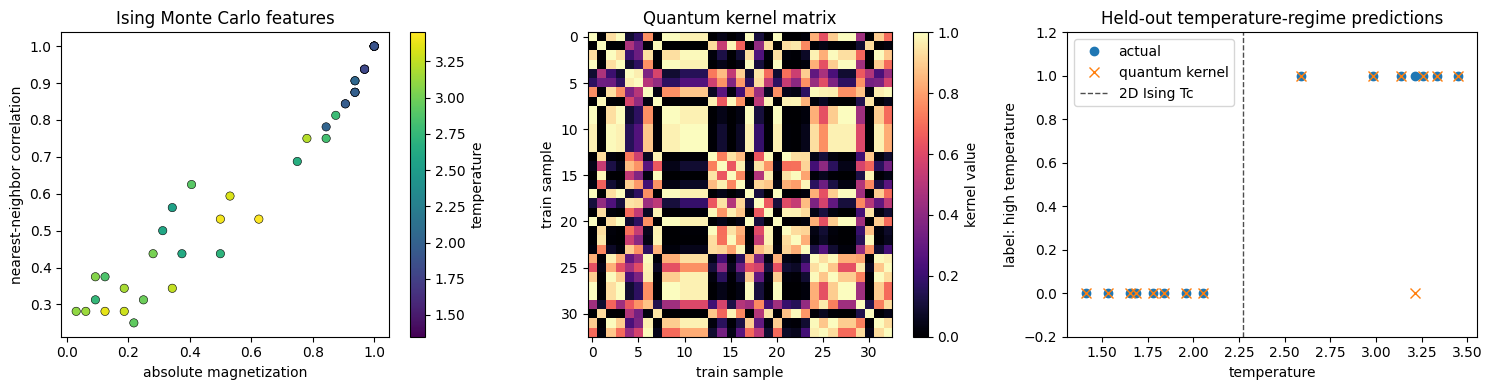

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter = axes[0].scatter(
    x_raw[:, 0],
    x_raw[:, 1],
    c=temperatures,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
)
axes[0].set_title("Ising Monte Carlo features")
axes[0].set_xlabel("absolute magnetization")
axes[0].set_ylabel("nearest-neighbor correlation")
fig.colorbar(scatter, ax=axes[0], label="temperature")

im = axes[1].imshow(k_train, cmap="magma", vmin=0.0, vmax=1.0)
axes[1].set_title("Quantum kernel matrix")
axes[1].set_xlabel("train sample")
axes[1].set_ylabel("train sample")
fig.colorbar(im, ax=axes[1], label="kernel value")

order = np.argsort(t_test)
axes[2].plot(t_test[order], y_test[order], "o", label="actual", markersize=6)
axes[2].plot(t_test[order], y_pred[order], "x", label="quantum kernel", markersize=7)
axes[2].axvline(2.269, color="0.3", linestyle="--", linewidth=1, label="2D Ising Tc")
axes[2].set_ylim(-0.2, 1.2)
axes[2].set_title("Held-out temperature-regime predictions")
axes[2].set_xlabel("temperature")
axes[2].set_ylabel("label: high temperature")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell confirms that the notebook generated Monte Carlo Ising features, built a valid quantum kernel, and achieved non-trivial temperature-regime classification accuracy.

In [6]:
validation = {
    "dataset": {
        "problem": "ising_temperature_regime_classification",
        "lattice_size": 8,
        "n_samples": int(len(y)),
        "feature_names": [
            "absolute_magnetization",
            "nearest_neighbor_correlation",
            "energy_density",
        ],
        "test_temperatures": np.round(t_test, 3).tolist(),
        "test_labels": y_test.astype(int).tolist(),
        "test_predictions": y_pred.astype(int).tolist(),
    },
    "results": results,
    "passed": bool(
        results["quantum_kernel_accuracy"] >= 0.80
        and results["kernel_diag_min"] > 0.99
        and results["kernel_symmetry_error"] < 1e-10
        and len(set(y_pred.tolist())) == 2
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Lattice size", validation["dataset"]["lattice_size"]),
        ("Samples", validation["dataset"]["n_samples"]),
        ("Feature names", validation["dataset"]["feature_names"]),
        ("Test temperatures", validation["dataset"]["test_temperatures"]),
        ("Test labels", validation["dataset"]["test_labels"]),
        ("Test predictions", validation["dataset"]["test_predictions"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum kernel accuracy", validation["results"]["quantum_kernel_accuracy"]),
        ("Logistic accuracy", validation["results"]["logistic_accuracy"]),
        ("Confusion matrix", validation["results"]["confusion_matrix"]),
        ("Kernel train shape", validation["results"]["kernel_train_shape"]),
        ("Kernel diagonal minimum", validation["results"]["kernel_diag_min"]),
        ("Kernel symmetry error", validation["results"]["kernel_symmetry_error"]),
    ],
)
print("Interpretation")
print(
    "The Ising features separate low- and high-temperature regimes for this small Monte Carlo dataset."
)
print(
    "The quantum kernel and logistic baseline are sanity-checked side by side; this validates workflow correctness, not quantum advantage."
)
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+-------------------+--------------------------------------------------------------------------------------------------------+
| Metric            | Value                                                                                                  |
+-------------------+--------------------------------------------------------------------------------------------------------+
| Problem           | ising_temperature_regime_classification                                                                |
| Lattice size      | 8                                                                                                      |
| Samples           | 48                                                                                                     |
| Feature names     | [absolute_magnetization, nearest_neighbor_correlation, energy_density]                                 |
| Test temperatures | [1.959, 1.685, 3.137, 2.05, 2.589, 3.333, 1.654, 3.254, 3.215, 1.533, 